In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
green_scr_img = cv.imread("../../../class.vision/images/green-sccreen.png")
bg_image = cv.imread("../../../class.vision/images/balloon.png")
green_scr_vid_pth = '../../../class.vision/videos/akhavan-green-bg.mp4'

70


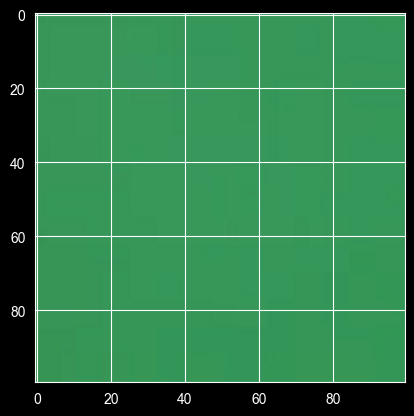

In [3]:
green_part = green_scr_img[100:200, 100:200]
plt.imshow(green_part[...,::-1])
green_part = cv.cvtColor(green_part, cv.COLOR_BGR2HSV)
green_mean_h = int(np.mean(green_part, axis=(0, 1))[0])
print(green_mean_h)

Text(0.5, 1.0, 'Added Object')

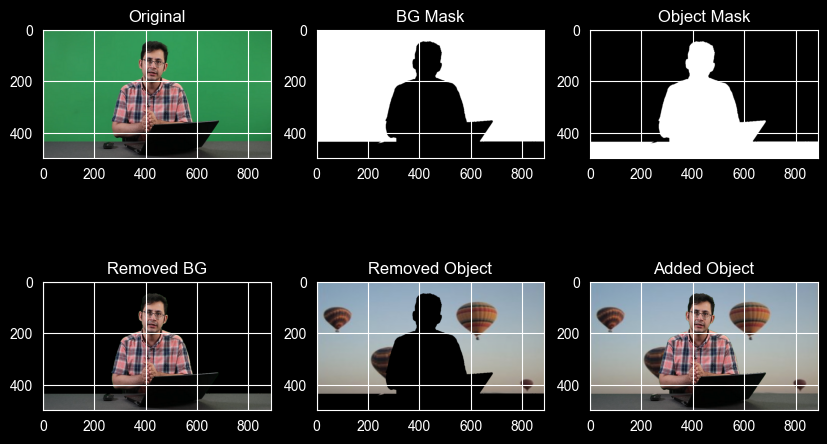

In [4]:
g_lower = np.array([green_mean_h - 10, 50, 50])
g_upper = np.array([green_mean_h + 10, 255, 255])

H, W = green_scr_img.shape[:2]
bg_image1 = cv.resize(bg_image, (W, H))

hsv_img = cv.cvtColor(green_scr_img, cv.COLOR_BGR2HSV)
mask = cv.inRange(hsv_img, g_lower, g_upper)
object_mask = cv.bitwise_not(mask)

removed_bg = cv.bitwise_and(green_scr_img, green_scr_img, mask=object_mask)
removed_obj = cv.bitwise_and(green_scr_img, green_scr_img, mask=mask)
bg_image1 = cv.bitwise_and(bg_image1, bg_image1, mask=mask)

final_img = cv.add(removed_bg, bg_image1)

plt.figure(figsize=[10,6])
plt.subplot(231);plt.imshow(green_scr_img[...,::-1]); plt.title("Original")
plt.subplot(232);plt.imshow(mask, cmap='gray'); plt.title("BG Mask")
plt.subplot(233);plt.imshow(object_mask, cmap='gray'); plt.title("Object Mask")
plt.subplot(234);plt.imshow(removed_bg[...,::-1]); plt.title("Removed BG")
plt.subplot(235);plt.imshow(bg_image1[..., ::-1]); plt.title("Removed Object")
plt.subplot(236);plt.imshow(final_img[...,::-1]); plt.title("Added Object")

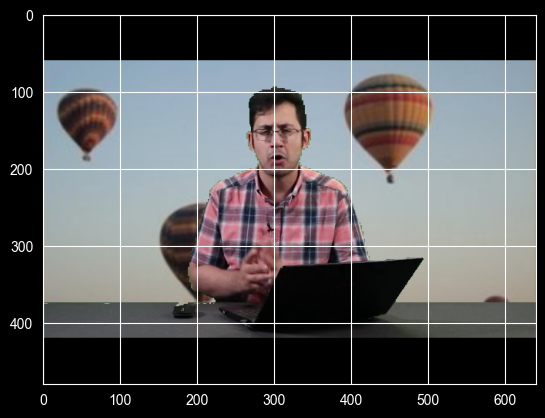

In [6]:
g_lower = np.array([green_mean_h - 10, 50, 50])
g_upper = np.array([green_mean_h + 10, 255, 255])

cap = cv.VideoCapture(green_scr_vid_pth)

frameWidth = cap.get(cv.CAP_PROP_FRAME_WIDTH)
frameHeight = cap.get(cv.CAP_PROP_FRAME_HEIGHT)
bg_image2 = cv.resize(bg_image, (int(frameWidth), int(frameHeight)))


while 1:
    ret, frame = cap.read()
    if not ret:
        break
    hsv_img = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    mask = cv.inRange(hsv_img, g_lower, g_upper)
    object_mask = cv.bitwise_not(mask)

    removed_bg = cv.bitwise_and(frame, frame, mask=object_mask)
    removed_obj = cv.bitwise_and(frame, frame, mask=mask)
    masked_bg_image = cv.bitwise_and(bg_image2, bg_image2, mask=mask)

    final_img = cv.add(removed_bg, masked_bg_image)
    cv.imshow("result", final_img)
    cv.waitKey(20)

cv.destroyAllWindows()
cap.release()

plt.imshow(final_img[...,::-1])

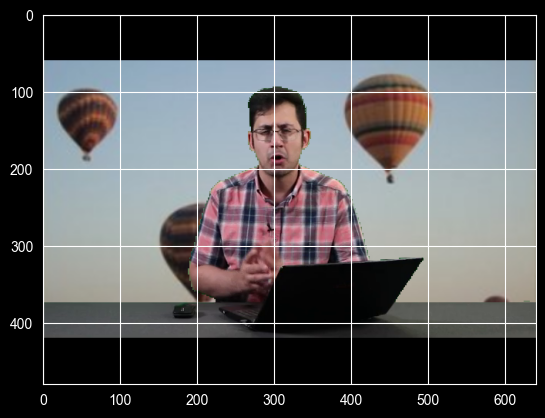

In [7]:
cap = cv.VideoCapture(green_scr_vid_pth)

frameWidth = cap.get(cv.CAP_PROP_FRAME_WIDTH)
frameHeight = cap.get(cv.CAP_PROP_FRAME_HEIGHT)
bg_image3 = cv.resize(bg_image, (int(frameWidth), int(frameHeight)))


while 1:
    ret, frame = cap.read()
    if not ret:
        break
    lab_img = cv.cvtColor(frame, cv.COLOR_BGR2LAB)
    L, A, B = cv.split(lab_img)
    # make green black (0)
    A_binary = cv.threshold(A, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)[1]
    A_binary_inv = cv.bitwise_not(A_binary)

    removed_bg = cv.bitwise_and(frame, frame, mask=A_binary)
    removed_obj = cv.bitwise_and(frame, frame, mask=A_binary_inv)
    masked_bg_image = cv.bitwise_and(bg_image3, bg_image3, mask=A_binary_inv)

    final_img = cv.add(removed_bg, masked_bg_image)
    cv.imshow("result", final_img)
    cv.waitKey(20)

cv.destroyAllWindows()
cap.release()

plt.imshow(final_img[...,::-1])